In [ ]:
!pip install qiskit qiskit-machine-learning imbalanced-learn


In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif

from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

from imblearn.over_sampling import SMOTE

from qiskit.circuit.library import ZZFeatureMap
from qiskit_machine_learning.kernels import FidelityQuantumKernel


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving cumulative.csv to cumulative (1).csv


In [ ]:
df = pd.read_csv("cumulative.csv")
df.head()


,rowid,kepid,kepoi_name,kepler_name,koi_disposition,koi_pdisposition,koi_score,koi_fpflag_nt,koi_fpflag_ss,koi_fpflag_co,...,koi_steff_err2,koi_slogg,koi_slogg_err1,koi_slogg_err2,koi_srad,koi_srad_err1,koi_srad_err2,ra,dec,koi_kepmag
0,1,10797460,K00752.01,Kepler-227 b,CONFIRMED,CANDIDATE,1.000,0,0,0,...,-81.0,4.467,0.064,-0.096,0.927,0.105,-0.061,291.93423,48.141651,15.347
1,2,10797460,K00752.02,Kepler-227 c,CONFIRMED,CANDIDATE,0.969,0,0,0,...,-81.0,4.467,0.064,-0.096,0.927,0.105,-0.061,291.93423,48.141651,15.347
2,3,10811496,K00753.01,NaN,FALSE POSITIVE,FALSE POSITIVE,0.000,0,1,0,...,-176.0,4.544,0.044,-0.176,0.868,0.233,-0.078,297.00482,48.134129,15.436
3,4,10848459,K00754.01,NaN,FALSE POSITIVE,FALSE POSITIVE,0.000,0,1,0,...,-174.0,4.564,0.053,-0.168,0.791,0.201,-0.067,285.53461,48.285210,15.597
4,5,10854555,K00755.01,Kepler-664 b,CONFIRMED,CANDIDATE,1.000,0,0,0,...,-211.0,4.438,0.070,-0.210,1.046,0.334,-0.133,288.75488,48.226200,15.509


Shape of dataset: (9564, 50)


Column Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9564 entries, 0 to 9563
Data columns (total 50 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   rowid              9564 non-null   int64  
 1   kepid              9564 non-null   int64  
 2   kepoi_name         9564 non-null   object 
 3   kepler_name        2294 non-null   object 
 4   koi_disposition    9564 non-null   object 
 5   koi_pdisposition   9564 non-null   object 
 6   koi_score          8054 non-null   float64
 7   koi_fpflag_nt      9564 non-null   int64  
 8   koi_fpflag_ss      9564 non-null   int64  
 9   koi_fpflag_co      9564 non-null   int64  
 10  koi_fpflag_ec      9564 non-null   int64  
 11  koi_period         9564 non-null   float64
 12  koi_period_err1    9110 non-null   float64
 13  koi_period_err2    9110 non-null   float64
 14  koi_time0bk        9564 non-null   float64
 15  koi_time0bk_err1   91

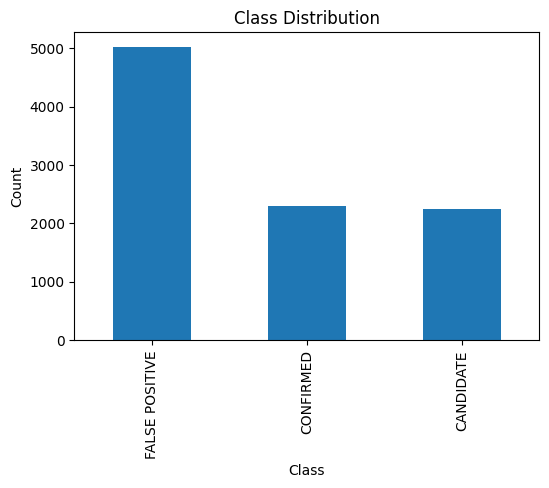

In [ ]:
print("Shape of dataset:", df.shape)
print("\n")

print("Column Information:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nClass Distribution:")
print(df['koi_disposition'].value_counts())

import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
df['koi_disposition'].value_counts().plot(kind='bar')
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

In [ ]:
df['target'] = (df['koi_disposition'] == 'CONFIRMED').astype(int)
drop_cols = [
    'rowid',
    'kepid',
    'kepoi_name',
    'kepler_name',
    'koi_disposition'
]

df = df.drop(columns=drop_cols)
print("Missing values before handling:")
print(df.isnull().sum().sum())

df = df.fillna(df.median(numeric_only=True))

print("\nMissing values after handling:")
print(df.isnull().sum().sum())

X = df.drop('target', axis=1)
y = df['target']

print("\nFeature matrix shape:", X.shape)
print("Target shape:", y.shape)

X.head()

Missing values before handling:
33287

Missing values after handling:
19474

Feature matrix shape: (9564, 45)
Target shape: (9564,)


,koi_pdisposition,koi_score,koi_fpflag_nt,koi_fpflag_ss,koi_fpflag_co,koi_fpflag_ec,koi_period,koi_period_err1,koi_period_err2,koi_time0bk,...,koi_steff_err2,koi_slogg,koi_slogg_err1,koi_slogg_err2,koi_srad,koi_srad_err1,koi_srad_err2,ra,dec,koi_kepmag
0,CANDIDATE,1.000,0,0,0,0,9.488036,2.775000e-05,-2.775000e-05,170.538750,...,-81.0,4.467,0.064,-0.096,0.927,0.105,-0.061,291.93423,48.141651,15.347
1,CANDIDATE,0.969,0,0,0,0,54.418383,2.479000e-04,-2.479000e-04,162.513840,...,-81.0,4.467,0.064,-0.096,0.927,0.105,-0.061,291.93423,48.141651,15.347
2,FALSE POSITIVE,0.000,0,1,0,0,19.899140,1.494000e-05,-1.494000e-05,175.850252,...,-176.0,4.544,0.044,-0.176,0.868,0.233,-0.078,297.00482,48.134129,15.436
3,FALSE POSITIVE,0.000,0,1,0,0,1.736952,2.630000e-07,-2.630000e-07,170.307565,...,-174.0,4.564,0.053,-0.168,0.791,0.201,-0.067,285.53461,48.285210,15.597
4,CANDIDATE,1.000,0,0,0,0,2.525592,3.761000e-06,-3.761000e-06,171.595550,...,-211.0,4.438,0.070,-0.210,1.046,0.334,-0.133,288.75488,48.226200,15.509


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

X_train = X_train.drop(columns=['koi_teq_err1', 'koi_teq_err2'])
X_val = X_val.drop(columns=['koi_teq_err1', 'koi_teq_err2'])

print("Remaining missing values in X_train:", X_train.isnull().sum().sum())

Remaining missing values in X_train: 267


In [ ]:
from imblearn.over_sampling import SMOTE

X_train_numeric = X_train.drop(columns=['koi_pdisposition', 'koi_tce_delivname'], errors='ignore')

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_numeric, y_train)

print("Shape after SMOTE:", X_train_smote.shape)
print("\nClass counts after SMOTE:")
print(y_train_smote.value_counts())

Shape after SMOTE: (11624, 41)

Class counts after SMOTE:
target
0    5812
1    5812
Name: count, dtype: int64


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_smote)

X_val_numeric = X_val.drop(columns=['koi_pdisposition', 'koi_tce_delivname'], errors='ignore')
X_val_scaled = scaler.transform(X_val_numeric)

In [ ]:
from sklearn.feature_selection import SelectKBest, f_classif

selector = SelectKBest(score_func=f_classif, k=8)

X_train_selected = selector.fit_transform(X_train_scaled, y_train_smote)
X_val_selected = selector.transform(X_val_scaled)

In [ ]:
selected_features = X_train_numeric.columns[selector.get_support()]

print("Selected Features:")
print(selected_features)

Selected Features:
Index(['koi_score', 'koi_fpflag_nt', 'koi_fpflag_ss', 'koi_fpflag_co',
       'koi_fpflag_ec', 'koi_steff_err1', 'koi_steff_err2', 'koi_slogg_err2'],
      dtype='object')


In [ ]:
from sklearn.svm import SVC

svm_classifier = SVC(
    kernel='rbf',
    random_state=42
)

svm_classifier.fit(X_train_selected, y_train_smote)

SVC(random_state=42)

In [ ]:
y_pred = svm_classifier.predict(X_val_selected)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accuracy = accuracy_score(y_val, y_pred)
precision = precision_score(y_val, y_pred)
recall = recall_score(y_val, y_pred)
f1 = f1_score(y_val, y_pred)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")

from sklearn.metrics import classification_report

print(classification_report(y_val, y_pred))



Accuracy : 0.8191
Precision: 0.5696
Recall   : 0.9736
F1-score : 0.7187
              precision    recall  f1-score   support

           0       0.99      0.77      0.87      1459
           1       0.57      0.97      0.72       454

    accuracy                           0.82      1913
   macro avg       0.78      0.87      0.79      1913
weighted avg       0.89      0.82      0.83      1913



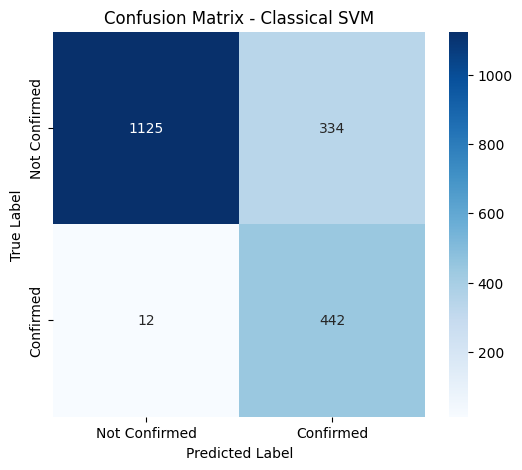

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_val, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Not Confirmed','Confirmed'],
    yticklabels=['Not Confirmed','Confirmed']
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Classical SVM")
plt.show()

In [ ]:
from qiskit.circuit.library import ZZFeatureMap
from qiskit_machine_learning.kernels import FidelityQuantumKernel

feature_map = ZZFeatureMap(
    feature_dimension=8,
    reps=2,
    entanglement="linear"
)

quantum_kernel = FidelityQuantumKernel(
    feature_map=feature_map
)

/tmp/ipykernel_34861/3515642034.py:4: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._zz_feature_map.ZZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the zz_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  feature_map = ZZFeatureMap(


In [ ]:
import numpy as np

np.random.seed(42)

quantum_train_idx = np.random.choice(X_train_selected.shape[0], size=150, replace=False)
X_train_q = X_train_selected[quantum_train_idx]
y_train_q = y_train_smote.iloc[quantum_train_idx].values


quantum_val_idx = np.random.choice(X_val_selected.shape[0], size=75, replace=False)
X_val_q = X_val_selected[quantum_val_idx]
y_val_q = y_val.iloc[quantum_val_idx].values

print("Quantum Train Class Balance:", np.bincount(y_train_q))
print("Quantum Validation Class Balance:", np.bincount(y_val_q))

Quantum Train Class Balance: [69 81]
Quantum Validation Class Balance: [55 20]


Computing quantum kernel matrices... (this may take a minute)
--- Quantum SVM Metrics ---
Accuracy  : 0.7867
Precision : 0.5588
Recall    : 0.9500
F1-score  : 0.7037

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.73      0.83        55
           1       0.56      0.95      0.70        20

    accuracy                           0.79        75
   macro avg       0.77      0.84      0.77        75
weighted avg       0.86      0.79      0.80        75



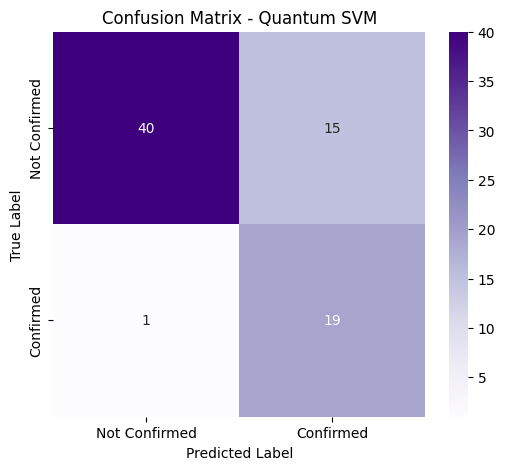

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Compute the quantum kernel matrices
print("Computing quantum kernel matrices... (this may take a minute)")
train_kernel = quantum_kernel.evaluate(x_vec=X_train_q, y_vec=X_train_q)
val_kernel = quantum_kernel.evaluate(x_vec=X_val_q, y_vec=X_train_q)

# Initialize and fit the SVM using the precomputed quantum kernel
q_svm = SVC(kernel='precomputed', random_state=42)
q_svm.fit(train_kernel, y_train_q)

# Predict using the precomputed validation kernel
y_pred_q = q_svm.predict(val_kernel)

accuracy_q = accuracy_score(y_val_q, y_pred_q)
precision_q = precision_score(y_val_q, y_pred_q, zero_division=0)
recall_q = recall_score(y_val_q, y_pred_q)
f1_q = f1_score(y_val_q, y_pred_q)

print("--- Quantum SVM Metrics ---")
print(f"Accuracy  : {accuracy_q:.4f}")
print(f"Precision : {precision_q:.4f}")
print(f"Recall    : {recall_q:.4f}")
print(f"F1-score  : {f1_q:.4f}\n")

print("Classification Report:")
print(classification_report(y_val_q, y_pred_q))

cm_q = confusion_matrix(y_val_q, y_pred_q)
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_q,
    annot=True,
    fmt='d',
    cmap='Purples',
    xticklabels=['Not Confirmed', 'Confirmed'],
    yticklabels=['Not Confirmed', 'Confirmed']
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Quantum SVM")
plt.show()

TASK 8: PERFORMANCE COMPARISON TABLE
   Metric  Classical SVM  Quantum SVM
 Accuracy         0.8191       0.7867
Precision         0.5696       0.5588
   Recall         0.9736       0.9500
 F1-Score         0.7187       0.7037




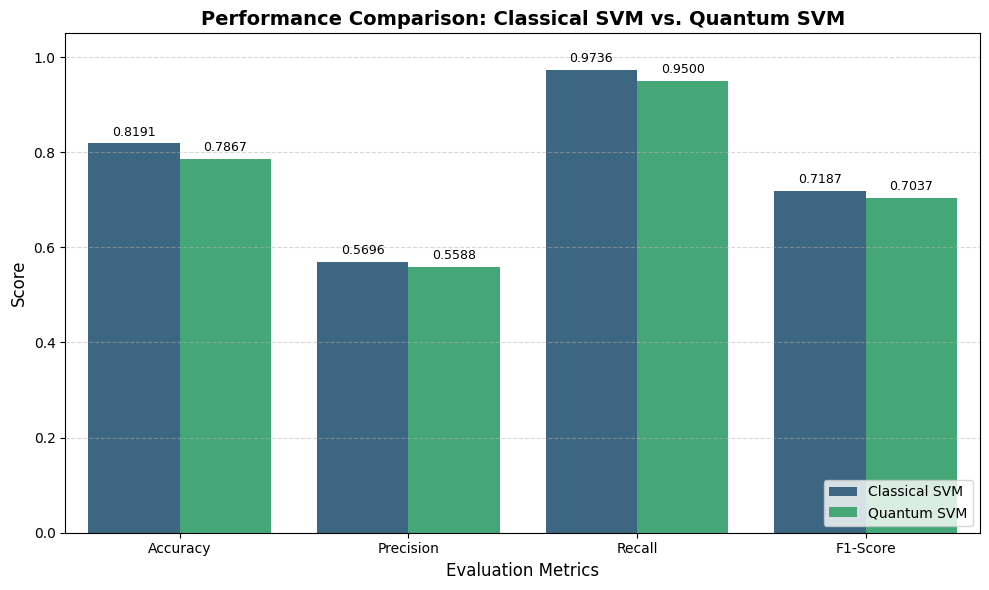

In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

metrics_data = {
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Classical SVM': [0.8191, 0.5696, 0.9736, 0.7187],
    'Quantum SVM': [0.7867, 0.5588, 0.9500, 0.7037]
}

df_metrics = pd.DataFrame(metrics_data)

print("TASK 8: PERFORMANCE COMPARISON TABLE")
print(df_metrics.to_string(index=False))
print("\n")

df_melted = df_metrics.melt(id_vars='Metric', var_name='Model', value_name='Score')

plt.figure(figsize=(10, 6))
sns.barplot(data=df_melted, x='Metric', y='Score', hue='Model', palette='viridis')

plt.ylim(0, 1.05)
plt.title('Performance Comparison: Classical SVM vs. Quantum SVM', fontsize=14, fontweight='bold')
plt.xlabel('Evaluation Metrics', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(loc='lower right')
for p in plt.gca().patches:
    height = p.get_height()
    if height > 0:
        plt.gca().annotate(f'{height:.4f}',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='center',
                    xytext=(0, 8),
                    textcoords='offset points', fontsize=9)

plt.tight_layout()
plt.show()

SUMMARY

So, as we can see clearly our classical SVM did perform better on this given dataset than the Quantum SVM . In statistical terms, we see that the Q-SVM gave an accuracy of 78.67% compared to the classical SVM's 81.91% while it had a precision of 55.88% compared to its classical counterpart's 56.96%.
However,the Q-SVM had a lot of limitations which if considered makes the Q-SVM look a more efficient model for evaluation  .
Due to the quantum kernel creation being computationally expensive it caused google colab's time limit for a session to get expired which caused a deletion of created variables like qsv from kernel memory of jupyter . i solved this problem by reducing the size of the dataset and a reduction of the dimension constraints which have interfered with the accuracy of the model quite a lot.
